In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os
import tensorflow

### LOAD DATA

In [2]:
import kagglehub

path = kagglehub.dataset_download("vbookshelf/rice-leaf-diseases")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'rice-leaf-diseases' dataset.
Path to dataset files: /kaggle/input/rice-leaf-diseases


In [3]:
print(os.listdir(path))

['rice_leaf_diseases']


In [4]:
data_dir = os.path.join(path, 'rice_leaf_diseases')

In [5]:
print(os.listdir(data_dir))

['Brown spot', 'Bacterial leaf blight', 'Leaf smut']


## CEK DATA PER KELAS

In [6]:
classes = os.listdir(data_dir)
print("Daftar Kelas Penyakit:", classes)

for disease_class in classes:
    class_path = os.path.join(data_dir, disease_class)
    num_images = len(os.listdir(class_path))
    print(f"Jumlah gambar untuk kelas {disease_class}: {num_images}")

Daftar Kelas Penyakit: ['Brown spot', 'Bacterial leaf blight', 'Leaf smut']
Jumlah gambar untuk kelas Brown spot: 40
Jumlah gambar untuk kelas Bacterial leaf blight: 40
Jumlah gambar untuk kelas Leaf smut: 40


## SAMPLE GAMBAR

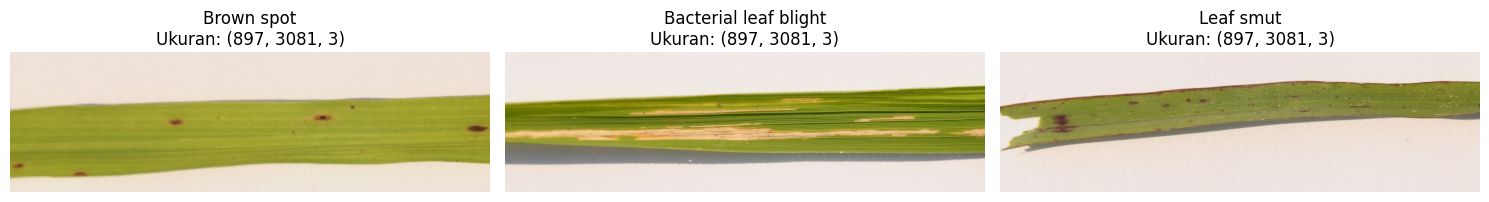

In [7]:
plt.figure(figsize=(15, 5))

for i, disease_class in enumerate(classes):
    class_path = os.path.join(data_dir, disease_class)
    sample_image_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, sample_image_name)

    img = mpimg.imread(img_path)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(f"{disease_class}\nUkuran: {img.shape}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## BAGI DATASET UNTUK TRAINING DAN VALIDASI

In [8]:
import tensorflow as tf

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

# Data untuk training (80%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Data untuk validasi (20%)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 120 files belonging to 3 classes.
Using 96 files for training.
Found 120 files belonging to 3 classes.
Using 24 files for validation.


## DATA AUGMENTATION DAN MODEL

In [9]:
from tensorflow.keras import layers, models

# 1. Bagian data augmentation
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.1),
])

In [10]:
num_classes = 3

# 2. Model CNN
model = models.Sequential([
  # 2.1 data augmentation
  data_augmentation,

  # 2.2 normalisasi ubah piksel dari 0-255 jadi 0-1
  layers.Rescaling(1./255, input_shape=(224, 224, 3)),

  # 2.3 fitur convolution dan pooling
  layers.Conv2D(16, (3,3), padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, (3,3), padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, (3,3), padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # 2.4 klasifikasi dari matrik menjadi array 1d
  layers.Flatten(),
  layers.Dense(128, activation='relu'),

  # output pake softmax karena kelas lebih dari 2
  layers.Dense(num_classes, activation='softmax')
])

# menampilkan ringkasan model
model.build(input_shape=(None, 224, 224, 3))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,446,627 (24.59 MB)

 Trainable params: 6,446,627 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

## KOMPILASI MODEL DAN FITTING

In [11]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

epochs = 15

print("Memulai proses training model...")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs
)

Memulai proses training model...
Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3854 - loss: 4.7328 - val_accuracy: 0.5417 - val_loss: 1.3494
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.2812 - loss: 1.5785 - val_accuracy: 0.1667 - val_loss: 1.1657
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3854 - loss: 1.0995 - val_accuracy: 0.1667 - val_loss: 1.2398
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3750 - loss: 1.0938 - val_accuracy: 0.2083 - val_loss: 1.1361
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3229 - loss: 1.0986 - val_accuracy: 0.5833 - val_loss: 1.0741
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3438 - loss: 1.1211 - val_accuracy: 0.1667 - val_loss: 1.1685
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.3750 - loss: 1.1014 - val_accuracy: 0.1667 - val_loss: 1.1754
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3958 - loss: 1.0840 - val_accuracy: 0.2917 - 

## PAKAI TRANSFER LEARNING MOBILENETV2

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model_transferlearning= models.Sequential([
    data_augmentation,
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])
model_transferlearning.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
model_transferlearning.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history_transferlearning = model_transferlearning.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5625 - loss: 1.0761 - val_accuracy: 0.5833 - val_loss: 0.8850
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6771 - loss: 0.7149 - val_accuracy: 0.7917 - val_loss: 0.5325
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8542 - loss: 0.4347 - val_accuracy: 0.5417 - val_loss: 0.9064
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.8750 - loss: 0.3379 - val_accuracy: 0.6250 - val_loss: 0.6689
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9271 - loss: 0.2369 - val_accuracy: 0.8750 - val_loss: 0.3726
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9375 - loss: 0.1992 - val_accuracy: 0.9167 - val_loss: 0.2993
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8958 - loss: 0.2115 - val_accuracy: 0.8333 - val_loss: 0.4675
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9583 - loss: 0.1260 - val_accuracy: 0.7083 - val_loss: 0.5472
Epoch 9/15
3/3 

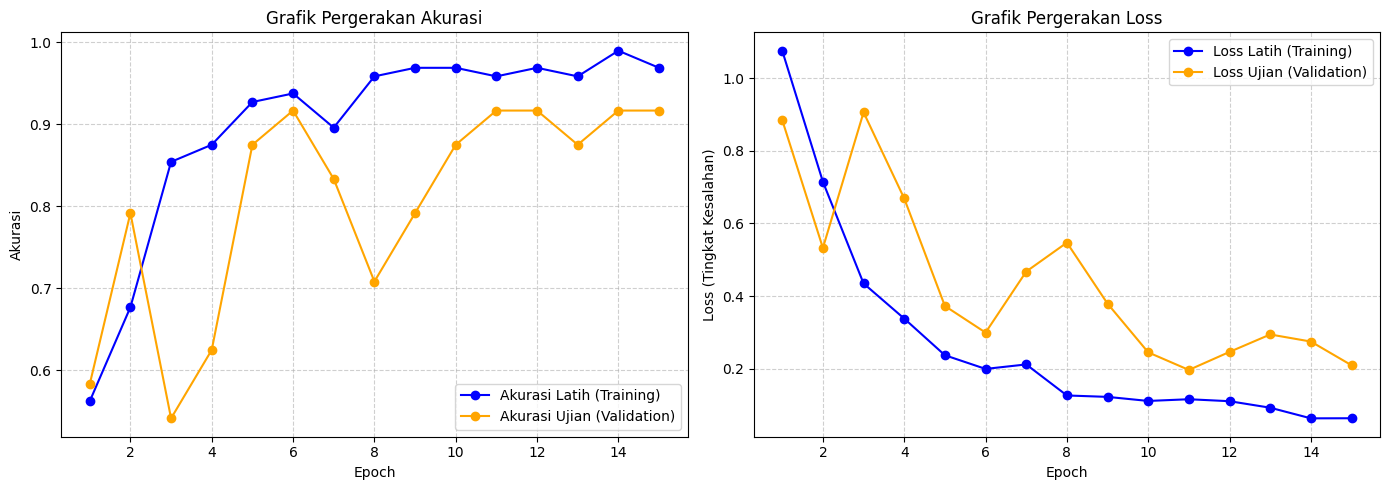

In [14]:
acc = history_transferlearning.history['accuracy']
val_acc = history_transferlearning.history['val_accuracy']
loss = history_transferlearning.history['loss']
val_loss = history_transferlearning.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Latih (Training)', marker='o', color='blue')
plt.plot(epochs_range, val_acc, label='Akurasi Ujian (Validation)', marker='o', color='orange')
plt.title('Grafik Pergerakan Akurasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Latih (Training)', marker='o', color='blue')
plt.plot(epochs_range, val_loss, label='Loss Ujian (Validation)', marker='o', color='orange')
plt.title('Grafik Pergerakan Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Tingkat Kesalahan)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

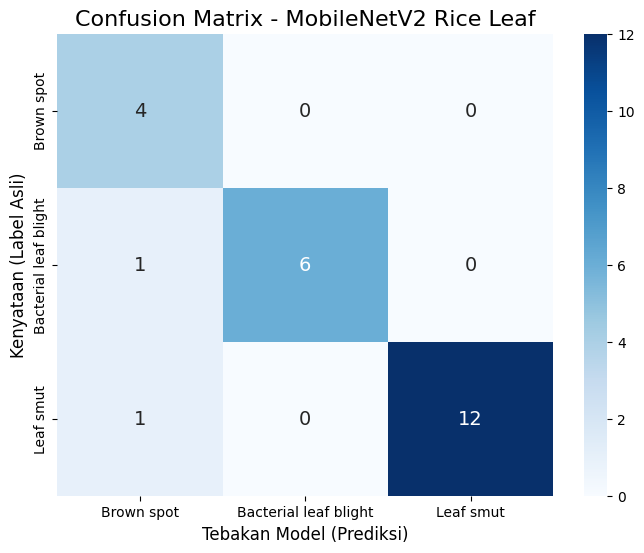


--- Classification Report ---
                       precision    recall  f1-score   support

           Brown spot       0.67      1.00      0.80         4
Bacterial leaf blight       1.00      0.86      0.92         7
            Leaf smut       1.00      0.92      0.96        13

             accuracy                           0.92        24
            macro avg       0.89      0.93      0.89        24
         weighted avg       0.94      0.92      0.92        24



In [15]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred_probs = []

for images, labels in validation_dataset:
    y_true.extend(labels.numpy())

    preds = model_transferlearning.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(y_pred_probs, axis=1)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            annot_kws={"size": 14})
plt.title('Confusion Matrix - MobileNetV2 Rice Leaf', fontsize=16)
plt.ylabel('Kenyataan (Label Asli)', fontsize=12)
plt.xlabel('Tebakan Model (Prediksi)', fontsize=12)
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=classes))